In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import norm

In [27]:
S = 100      # stock price
K = 100      # strike price
T = 1        # time to expiry in years
r = 0.05     # risk-free rate
sigma = 0.20 # volatility

In [28]:
# d1 and d2
d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - (sigma*(np.sqrt(T)))

print(d1)
print(d2)

0.35000000000000003
0.15000000000000002


In [31]:
# N(d1) and N(d2)

Nd1 = norm.cdf(d1)
Nd2 = norm.cdf(d2)

print(Nd1)
print(Nd2)

0.6368306511756191
0.5596176923702425


In [33]:
# Call price

Call_price = S*Nd1 - K*np.exp(-r*T)*Nd2
print(Call_price)

10.450583572185565


In [36]:
# Put price

Put_price = K*np.exp(-r*T)* norm.cdf(-d2)-S*norm.cdf(-d1)
print(Put_price)

5.573526022256971


In [38]:
# PUT-Call parity

lhs = Call_price - Put_price
rhs = S - K*np.exp(-r*T)

print(lhs)
print(rhs)

4.877057549928594
4.877057549928594


In [39]:
# Delta Call/Put

delta_call = norm.cdf(d1)
delta_put = norm.cdf(d1) - 1

print(delta_call)
print(delta_put)

0.6368306511756191
-0.3631693488243809


In [40]:
# Gamma

gamma = norm.pdf(d1)/(S*sigma*np.sqrt(T))
print(gamma)

0.018762017345846895


In [43]:
# Theta Call/Put

theta_call = ((-S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)))- r*K*np.exp(-r*T)*norm.cdf(d2)
theta_put = ((-S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)))+ r*K*np.exp(-r*T)*norm.cdf(-d2)

print(theta_call)
print(theta_put)


-6.414027546438197
-1.657880423934626


In [45]:
# Vega

vega = S* norm.pdf(d1)*np.sqrt(T)
print(vega)

37.52403469169379


In [46]:
# Rho Call/Put

rho_call = K*T*np.exp(-r*T)* norm.cdf(d2)
rho_put = -K*T*np.exp(-r*T)* norm.cdf(-d2)

print(rho_call)
print(rho_put)

53.232481545376345
-41.89046090469506


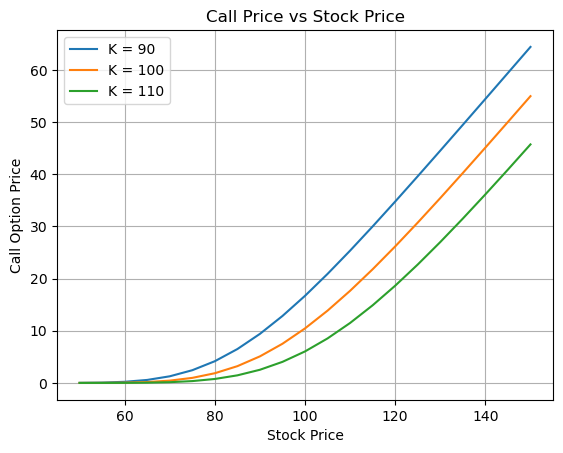

In [47]:
# Plot option price vs spot for multiple strikes

import matplotlib.pyplot as plt

spot_prices = np.arange(50, 151, 5)
strikes = [90, 100, 110]

for K in strikes:
    call_prices = []

    for S in spot_prices:
        d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)

        call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
        call_prices.append(call_price)

    plt.plot(spot_prices, call_prices, label=f"K = {K}")

plt.xlabel("Stock Price")
plt.ylabel("Call Option Price")
plt.title("Call Price vs Stock Price")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# Delta sensitivity table when volatility changes

S = 100
K = 100
T = 1
r = 0.05

vols = [0.10, 0.20, 0.30, 0.40, 0.50]

for sigma in vols:
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))

    call_delta = norm.cdf(d1)
    put_delta = norm.cdf(d1) - 1

    print(sigma, call_delta, put_delta)

0.1 0.7088403132116536 -0.29115968678834636
0.2 0.6368306511756191 -0.3631693488243809
0.3 0.6242517279060125 -0.37574827209398753
0.4 0.627409464153284 -0.372590535846716
0.5 0.6368306511756191 -0.3631693488243809
